In [ ]:
Завдання 1. Завантажте набір даних cars.csv в pandas.DataFrame. Виведіть перші 5 записів.

In [4]:
import pandas as pd

cars_df = pd.read_csv(r'C:\Users\user\Desktop\python\jup\cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


Завдання 2. Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип object може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

In [5]:
cars_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Car_ID             100 non-null    int64
 1   Brand              100 non-null    str  
 2   Model              100 non-null    str  
 3   Year               100 non-null    int64
 4   Kilometers_Driven  100 non-null    int64
 5   Fuel_Type          100 non-null    str  
 6   Transmission       100 non-null    str  
 7   Owner_Type         100 non-null    str  
 8   Mileage            100 non-null    int64
 9   Engine             100 non-null    int64
 10  Power              100 non-null    int64
 11  Seats              100 non-null    int64
 12  Price              100 non-null    int64
dtypes: int64(8), str(5)
memory usage: 10.3 KB


In [6]:
categorical_cols = cars_df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"{col}: {cars_df[col].nunique()} унікальних значень")
    print(cars_df[col].unique()[:10]) 
    print()

Brand: 11 унікальних значень
<StringArray>
[    'Toyota',      'Honda',       'Ford',     'Maruti',    'Hyundai',
       'Tata',   'Mahindra', 'Volkswagen',       'Audi',        'BMW']
Length: 10, dtype: str

Model: 58 унікальних значень
<StringArray>
['Corolla',   'Civic', 'Mustang',   'Swift',  'Sonata',   'Nexon', 'Scorpio',
    'Polo',      'A4',      'X1']
Length: 10, dtype: str

Fuel_Type: 2 унікальних значень
<StringArray>
['Petrol', 'Diesel']
Length: 2, dtype: str

Transmission: 2 унікальних значень
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

Owner_Type: 3 унікальних значень
<StringArray>
['First', 'Second', 'Third']
Length: 3, dtype: str



C:\Users\user\AppData\Local\Temp\ipykernel_25240\3907657657.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = cars_df.select_dtypes(include='object').columns


В наборі даних 8 числових і 5 категоріальних колонок, з них
- 2 бінарні (Fuel_Type, Transmission — мають лише 2 значення)
- 2 мультикатегоріальні (Brand, Model) зі значеннями, для яких немає відношення порядку
- 1 колонка (Owner_Type), в якій можна встановити відношення порядку (First < Second < Third)

Завдання 3. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте random_state=12. Ми будемо передбачати колонку Price - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних X_train, X_test, y_train, y_test.

In [7]:
from sklearn.model_selection import train_test_split

X = cars_df.drop(columns=['Price'])
y = cars_df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

Завдання 4. Кодуємо категоріальні колонки.
1. Закодуйте колонки з бінарними значеннями Fuel_Type і Transmission так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку Brand з використанням sklearn.preprocessing.OneHotEncoder аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу Encoder.fit() на тренувальних даних X_train, а на тестувальних тільки викликаємо Encoder.transform(). Додайте закодовані значення в набори даних X_train, X_test.

3. Колонку Owner_Type з використанням sklearn.preprocessing.OrdinalEncoder я закодую для вас. Проаналізуйте, що відбувається.

In [11]:
#1
print(X_train['Fuel_Type'].value_counts())
print(X_train['Transmission'].value_counts())

X_train['Fuel_Type_Code'] = (X_train['Fuel_Type'] == 'Petrol').astype(int)
X_test['Fuel_Type_Code'] = (X_test['Fuel_Type'] == 'Petrol').astype(int)

X_train['Transmission_Code'] = (X_train['Transmission'] == 'Automatic').astype(int)
X_test['Transmission_Code'] = (X_test['Transmission'] == 'Automatic').astype(int)

Fuel_Type
Petrol    41
Diesel    39
Name: count, dtype: int64
Transmission
Automatic    49
Manual       31
Name: count, dtype: int64


In [12]:
#2
from sklearn import preprocessing

enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])  
enc.categories_

one_hot_train = enc.transform(X_train[['Brand']]).toarray()
one_hot_train

one_hot_test = enc.transform(X_test[['Brand']]).toarray()
one_hot_test

X_train[enc.categories_[0]] = one_hot_train
X_test[enc.categories_[0]] = one_hot_test

In [13]:
#3
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']])
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Завдання 5. Оберіть лише числові колонки з X_train (можна для цього використати pandas.select_dtypes(...) або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з y_train (зручно з pandas.concat([df1, df2], axis=1)), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [15]:
import pandas as pd

numeric_X_train = X_train.select_dtypes(include=['int64', 'float64'])

df_corr = pd.concat([numeric_X_train, y_train], axis=1)

corr_matrix = df_corr.corr()

print(corr_matrix['Price'].sort_values(ascending=False))

Price                1.000000
Power                0.849137
Engine               0.710561
Transmission_Code    0.680731
BMW                  0.477522
Mercedes             0.431606
Audi                 0.328858
Car_ID               0.025560
Seats                0.000979
Ford                -0.004592
Toyota              -0.023778
Kilometers_Driven   -0.083951
Fuel_Type_Code      -0.110782
Volkswagen          -0.158742
Mahindra            -0.178627
Honda               -0.209779
Year                -0.233769
Maruti              -0.249737
Hyundai             -0.263022
Owner_Type_Codes    -0.265537
Tata                -0.341815
Mileage             -0.638404
Name: Price, dtype: float64


- Найбільше з Price корелюють колонки Power і Engine  — позитивна кореляція. Кращий двигун = вища ціна.
- Kilometers_Driven корелює негативно. Це знчить чим більший пробіг машини, тим нижча її ціна.

Завдання 6. Тренуємо лінійну регресію. 0. Видаліть усі НЕчислові колонки з X_train, X_test, якщо ще цього не зробили.

- Натренуйте лінійну регресую з sklearn на усіх числових даних тренувального набору X_train.
- Зробіть передбачення на X_train, X_test. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
- Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

X_train_num = X_train.select_dtypes(include=['int64', 'float64'])
X_test_num = X_test.select_dtypes(include=['int64', 'float64'])

lin_reg = LinearRegression()
lin_reg.fit(X_train_num, y_train)

pred_train = lin_reg.predict(X_train_num)
pred_test = lin_reg.predict(X_test_num)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print(f"RMSE (train): {rmse_train:.2f}")
print(f"RMSE (test): {rmse_test:.2f}")

RMSE (train): 210293.58
RMSE (test): 258181.56


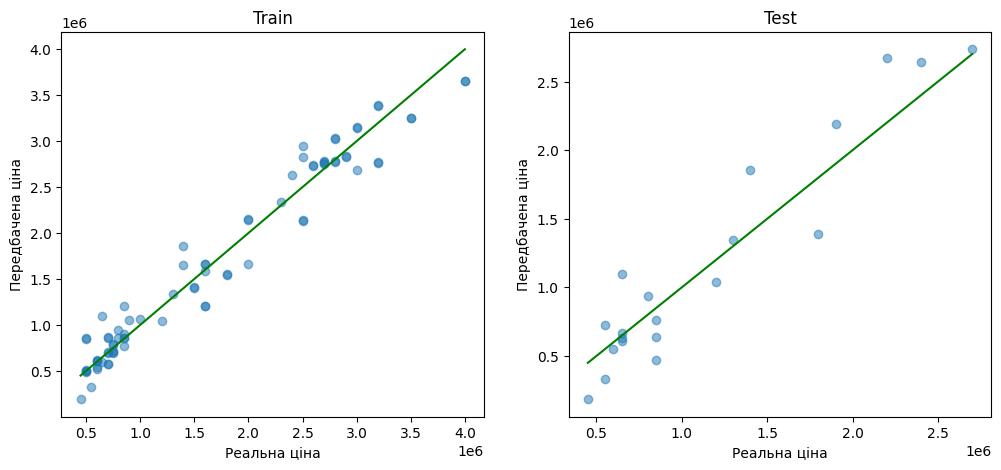

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_train, pred_train, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='green')
axes[0].set_xlabel('Реальна ціна')
axes[0].set_ylabel('Передбачена ціна')
axes[0].set_title('Train')

axes[1].scatter(y_test, pred_test, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='green')
axes[1].set_xlabel('Реальна ціна')
axes[1].set_ylabel('Передбачена ціна')
axes[1].set_title('Test')

plt.show()

Завдання 7. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.

- Зробіть масштабування незалежних змінних використовуючи StandardScaler. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо transform.

- Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_num)

X_train_scaled = scaler.transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'feature': X_train_num.columns,
    'coefficient': lin_reg_scaled.coef_
}).sort_values(by='coefficient', key=abs, ascending=False)

print(coef_df)

              feature    coefficient
5               Power  496769.214899
14           Mercedes  210048.781148
8                 BMW  208407.313783
7                Audi  205600.147769
18     Fuel_Type_Code -183848.018909
11            Hyundai -152304.863911
12           Mahindra -140945.162904
3             Mileage -131715.512030
9                Ford -118209.450311
19  Transmission_Code  116693.768206
13             Maruti -112259.967020
2   Kilometers_Driven  -94398.721486
17         Volkswagen  -92968.260065
15               Tata  -65996.246972
10              Honda  -62753.005386
20   Owner_Type_Codes   42344.952815
4              Engine  -21377.453338
16             Toyota   15805.701511
1                Year   -8765.645714
0              Car_ID    5608.685421
6               Seats   -2148.924549


Завдання 8. На тих самих відмасштабованих даних натренуйте модель з statsmodels. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [28]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_scaled)
model_sm = sm.OLS(y_train.values, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     68.35
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           2.01e-33
Time:                        17:18:12   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2230.
Df Residuals:                      59   BIC:                             2280.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.68e+06   2.74e+04     61.363      0.0

In [29]:

p_values = pd.Series(model_sm.pvalues[1:], index=X_train_num.columns)
significant_features = p_values[p_values < 0.05].index.tolist()

print("Статистично значущі ознаки (p < 0.05):")
print(significant_features)

Статистично значущі ознаки (p < 0.05):
['Mileage', 'Power', 'Audi', 'BMW', 'Ford', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Volkswagen', 'Fuel_Type_Code', 'Transmission_Code']


Завдання 9. Натренуйте лінійну регресію з statsmodels тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [31]:
X_train_sig = X_train_num[significant_features]
X_test_sig = X_test_num[significant_features]

scaler_sig = StandardScaler()
scaler_sig.fit(X_train_sig)
X_train_sig_scaled = scaler_sig.transform(X_train_sig)

X_train_sig_sm = sm.add_constant(X_train_sig_scaled)

model_sig = sm.OLS(y_train.values, X_train_sig_sm).fit()
print(model_sig.summary())

print(f"R-squared (завдання 8, усі ознаки): {model_sm.rsquared:.4f}")
print(f"R-squared (завдання 9, тільки значущі): {model_sig.rsquared:.4f}")
print(f"Adj. R-squared (завдання 8): {model_sm.rsquared_adj:.4f}")
print(f"Adj. R-squared (завдання 9): {model_sig.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           4.12e-39
Time:                        17:19:30   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.68e+06   2.78e+04     60.360      0.0

R2 зменьшився, Adj.R-squared також зменьшився, але не значно. Прибрані ознаки не мали суттєвого впливу н варіації ціни.

Завдання 10. Натренуйте лінійну регресію з statsmodels на усіх ознаках з масштабованого X_train, у яких p_value в завданні 8 менше за 0.25. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [32]:
relaxed_features = p_values[p_values < 0.25].index.tolist()
print("Ознаки з p < 0.25:")
print(relaxed_features)

X_train_relaxed = X_train_num[relaxed_features]
scaler_relaxed = StandardScaler()
scaler_relaxed.fit(X_train_relaxed)
X_train_relaxed_scaled = scaler_relaxed.transform(X_train_relaxed)

X_train_relaxed_sm = sm.add_constant(X_train_relaxed_scaled)

model_relaxed = sm.OLS(y_train.values, X_train_relaxed_sm).fit()
print(model_relaxed.summary())

print(f"R-squared (p<0.05, завдання 9): {model_sig.rsquared:.4f}")
print(f"R-squared (p<0.25, завдання 10): {model_relaxed.rsquared:.4f}")
print(f"Adj. R-squared (завдання 9): {model_sig.rsquared_adj:.4f}")
print(f"Adj. R-squared (завдання 10): {model_relaxed.rsquared_adj:.4f}")

Ознаки з p < 0.25:
['Kilometers_Driven', 'Mileage', 'Power', 'Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Tata', 'Volkswagen', 'Fuel_Type_Code', 'Transmission_Code']
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           4.85e-38
Time:                        17:21:59   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
           

Додавання ознак з меньшим порогом збільшило R2 і Adj. R-squared. це означає що данні ознаки збільшують корисність інформації.